<a href="https://colab.research.google.com/github/yamanjoshi41/Business-Strategy-Game-Simulation/blob/main/visualizations_bsg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

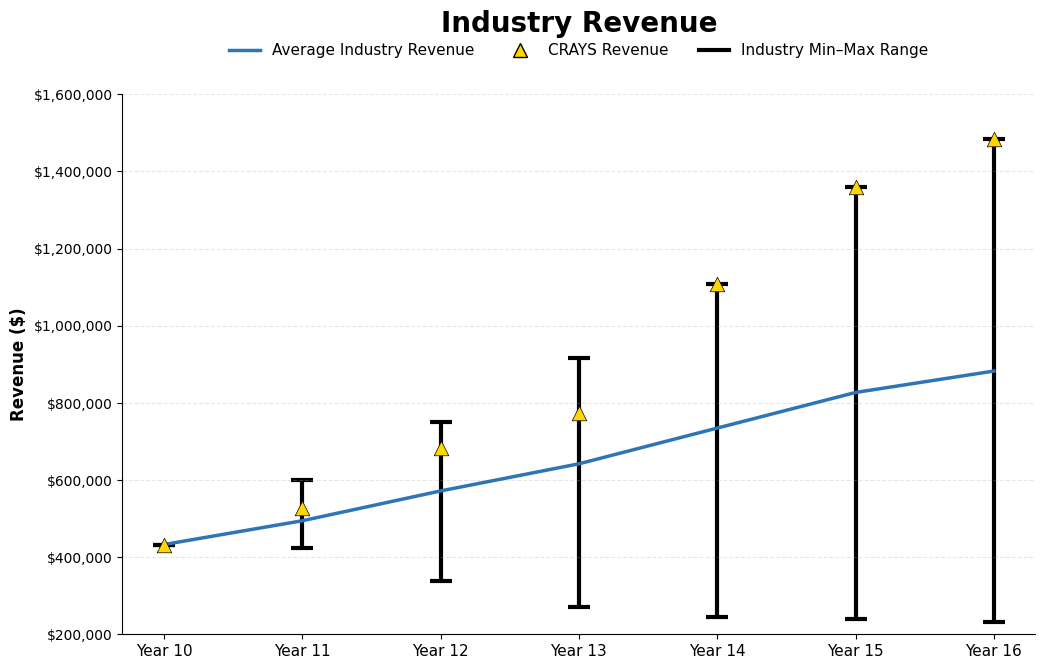

In [3]:
"""
Industry Revenue chart:
- Blue line  = Average Industry Revenue
- Gold triangles = CRAYS Revenue
- Black error bars = Industry revenue range (min/max) around the average
"""

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ---- 1. Data ----
years = ["Year 10", "Year 11", "Year 12", "Year 13", "Year 14", "Year 15", "Year 16"]

# Company C (CRAYS Athletics) Net Sales Revenues Total
crays_revenue = [432646, 526645, 681942, 774898, 1109359, 1360881, 1483316]

# Minimum Net Sales Revenues across all companies in Industry 12
industry_min = [432646, 423289, 336951, 271906, 245595, 240756, 231316]

# Maximum Net Sales Revenues across all companies in Industry 12
industry_max = [432646, 601083, 749656, 917540, 1109359, 1360881, 1483316]

# Official Industry Average Net Sales Revenues
avg_industry_revenue = [432646, 494301, 571616, 641931, 734600, 826928, 882439]

x = range(len(years))

# Error bar distances
lower_err = [avg - lo for avg, lo in zip(avg_industry_revenue, industry_min)]
upper_err = [hi - avg for hi, avg in zip(industry_max, avg_industry_revenue)]

# ---- 2. Plot ----
fig, ax = plt.subplots(figsize=(11, 7.5))

# Industry Range
ax.errorbar(
    x,
    avg_industry_revenue,
    yerr=[lower_err, upper_err],
    fmt="none",
    ecolor="black",
    elinewidth=3,
    capsize=8,
    capthick=3,
    zorder=1
)

# Industry Average
ax.plot(
    x,
    avg_industry_revenue,
    color="#2E75B6",
    linewidth=2.5,
    label="Average Industry Revenue",
    zorder=2
)

# CRAYS Revenue
ax.scatter(
    x,
    crays_revenue,
    color="#FFD700",
    marker="^",
    s=110,
    edgecolors="black",
    linewidths=0.5,
    label="CRAYS Revenue",
    zorder=3
)

# ---- 3. Formatting ----
ax.set_title(
    "Industry Revenue",
    fontsize=20,
    fontweight="bold",
    pad=45
)

ax.set_ylabel(
    "Revenue ($)",
    fontsize=12,
    fontweight="bold"
)

ax.set_xticks(list(x))
ax.set_xticklabels(years, fontsize=11)

# ==========================
# UPDATED SCALE ONLY
# ==========================
ax.set_ylim(200000, 1600000)

# Tick every $200,000
ax.yaxis.set_major_locator(mticker.MultipleLocator(200000))

# Display as normal dollars
ax.yaxis.set_major_formatter(
    mticker.StrMethodFormatter('${x:,.0f}')
)

# ==========================

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    handles=[
        Line2D([0], [0],
               color="#2E75B6",
               linewidth=2.5,
               label="Average Industry Revenue"),

        Line2D([0], [0],
               marker="^",
               color="w",
               markerfacecolor="#FFD700",
               markeredgecolor="black",
               markersize=10,
               label="CRAYS Revenue"),

        Line2D([0], [0],
               color="black",
               linewidth=3,
               label="Industry Min–Max Range"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=3,
    frameon=False,
    fontsize=11
)

plt.subplots_adjust(
    top=0.82,
    bottom=0.10,
    left=0.12,
    right=0.95
)

plt.savefig(
    "industry_revenue_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

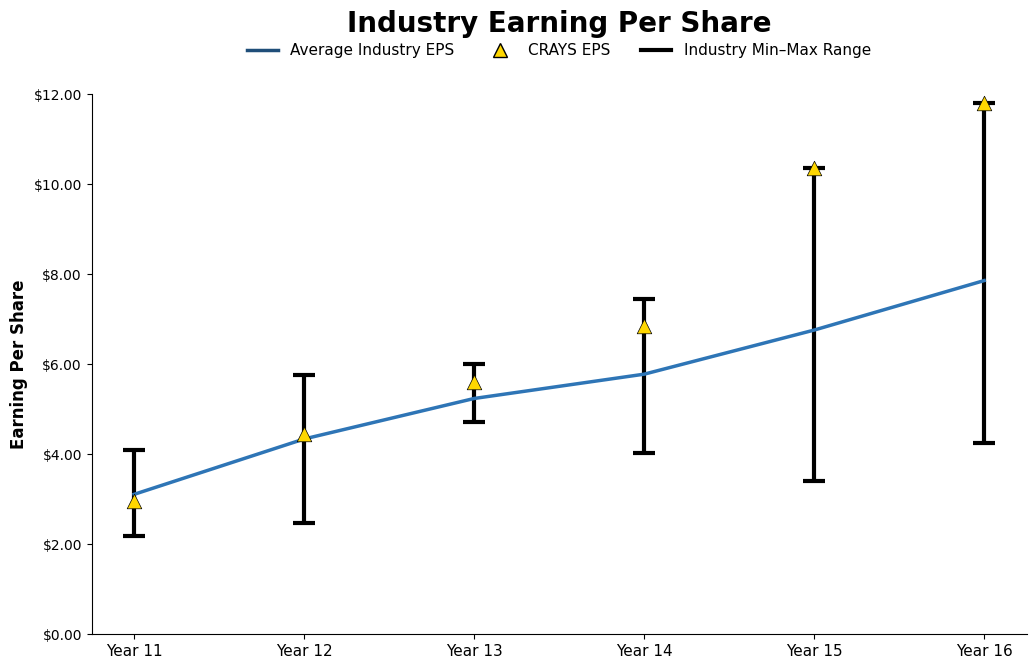

In [4]:
"""
Industry Stock Price chart:
- Dark blue line   = Average Industry EPS
- Dark gold diamonds = Crays EPS (Company C)
- Black error bars = Industry EPS range (min/max) around the average
"""

# ---- 1. Data ----
years = ["Year 11", "Year 12", "Year 13", "Year 14", "Year 15", "Year 16"]

avg_industry_stock = [3.11, 4.34, 5.24, 5.78, 6.76, 7.86]

# Min/Max industry stock price range (used to draw the error bars)
industry_min = [2.19, 2.47, 4.72, 4.02, 3.40, 4.25]
industry_max = [4.10, 5.77, 6.01, 7.44, 10.36, 11.80]

crays_stock = [2.97, 4.46, 5.61, 6.86, 10.36, 11.80]

x = range(len(years))

# Error bar distances (must be non-negative, relative to avg line)
lower_err = [avg - lo for avg, lo in zip(avg_industry_stock, industry_min)]
upper_err = [hi - avg for avg, hi in zip(avg_industry_stock, industry_max)]

# ---- 2. Plot ----
fig, ax = plt.subplots(figsize=(11, 7.5))

# Black error bars (industry range) — plotted first so line/markers sit on top
ax.errorbar(
    x, avg_industry_stock,
    yerr=[lower_err, upper_err],
    fmt="none", ecolor="black", elinewidth=3, capsize=8, capthick=3, zorder=1
)

# Dark blue line — Average Industry Stock Price
ax.plot(
    x, avg_industry_stock,
    color="#2E75B6", linewidth=2.5, label="Average Industry EPS", zorder=2
)

# Dark gold diamonds — Crays Stock Price
ax.scatter(
    x, crays_stock,
    color="#FFD700", marker="^", s=110, label="CRAYS EPS",
    edgecolors="black", linewidths=0.5, zorder=3
)

# ---- 3. Formatting ----
ax.set_title("Industry Earning Per Share", fontsize=20, fontweight="bold", pad=45)
ax.set_ylabel("Earning Per Share", fontsize=12, fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(years, fontsize=11)

ax.set_ylim(0, 12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"${v:,.2f}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.12),
    ncol=2, frameon=False, fontsize=12
)
from matplotlib.lines import Line2D
range_line = Line2D([0], [0], color='black', linewidth=3, label='Industry Min–Max Range')

ax.legend(
    handles=[
        Line2D([0], [0], color='#1F4E79', linewidth=2.5, label='Average Industry EPS'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#FFD700',
               markeredgecolor='black', markersize=10, label='CRAYS EPS'),
        range_line
    ],
    loc="upper center", bbox_to_anchor=(0.5, 1.12),
    ncol=3, frameon=False, fontsize=11
)
plt.subplots_adjust(top=0.82, bottom=0.1, left=0.1, right=0.95)
plt.savefig("industry_stock_chart.png", dpi=200)
plt.show()

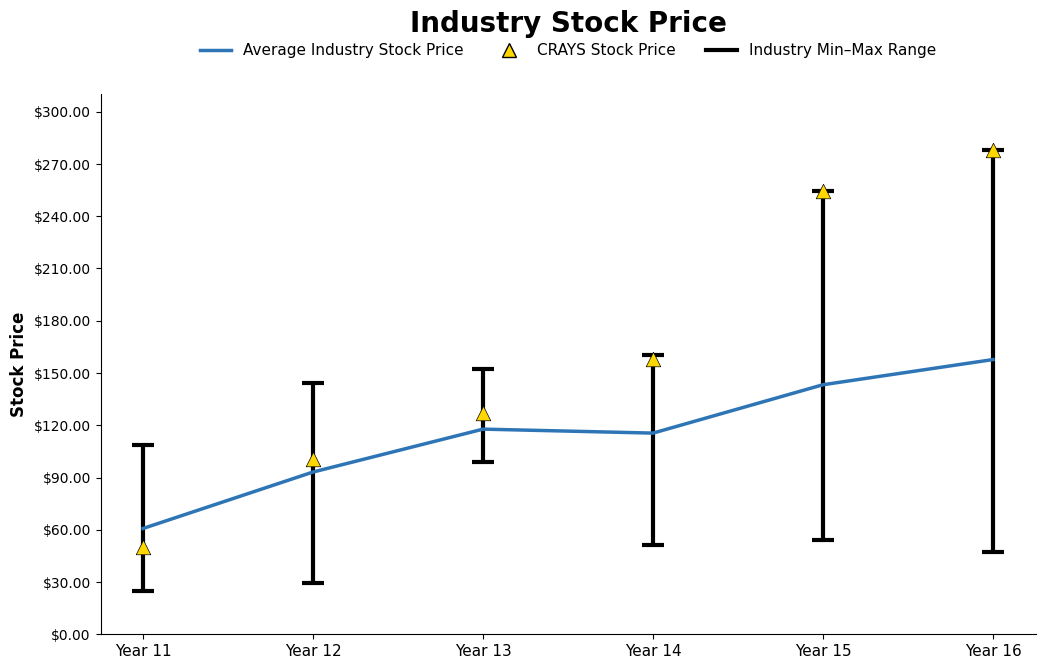

In [5]:
"""
Industry Stock Price chart:
- Dark blue line   = Average Industry Stock Price
- Dark gold diamonds = Crays Stock Price (Company C)
- Black error bars = Industry stock price range (min/max) around the average
"""

# ---- 1. Data ----
years = ["Year 11", "Year 12", "Year 13", "Year 14", "Year 15", "Year 16"]
avg_industry_stock = [60.74, 93.14, 117.77, 115.49, 143.26, 157.71]
# Min/Max industry stock price range (used to draw the error bars)
industry_min = [24.76, 29.38, 99.17, 51.52, 54.10, 47.17]
industry_max = [108.41, 144.49, 152.42, 160.49, 254.55, 277.73]
crays_stock = [49.83, 100.54, 127.12, 157.90, 254.55, 277.73]

x = range(len(years))

# Error bar distances (must be non-negative, relative to avg line)
lower_err = [avg - lo for avg, lo in zip(avg_industry_stock, industry_min)]
upper_err = [hi - avg for avg, hi in zip(avg_industry_stock, industry_max)]

# ---- 2. Plot ----
fig, ax = plt.subplots(figsize=(11, 7.5))

# Black error bars (industry range) — plotted first so line/markers sit on top
ax.errorbar(
    x, avg_industry_stock,
    yerr=[lower_err, upper_err],
    fmt="none", ecolor="black", elinewidth=3, capsize=8, capthick=3, zorder=1
)

# Dark blue line — Average Industry Stock Price
ax.plot(
    x, avg_industry_stock,
    color="#2E75B6", linewidth=2.5, label="Avg Industry Stock Price", zorder=2
)

# Dark gold diamonds — Crays Stock Price
ax.scatter(
    x, crays_stock,
    color="#FFD700", marker="^", s=110, label="Crays Stock Price",
    edgecolors="black", linewidths=0.5, zorder=3
)

# ---- 3. Formatting ----
ax.set_title("Industry Stock Price", fontsize=20, fontweight="bold", pad=45)
ax.set_ylabel("Stock Price", fontsize=12, fontweight="bold")
ax.set_xticks(list(x))
ax.set_xticklabels(years, fontsize=11)

# Scale fixed to fit the full data range (including new Year 16 max of 277.73)
ax.set_ylim(0, 310)
ax.yaxis.set_major_locator(mticker.MultipleLocator(30))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"${v:,.2f}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    handles=[
        Line2D([0], [0], color="#2E75B6", linewidth=2.5, label="Average Industry Stock Price"),
        Line2D([0], [0], marker="^", color="w", markerfacecolor="#FFD700",
               markeredgecolor="black", markersize=10, label="CRAYS Stock Price"),
        Line2D([0], [0], color="black", linewidth=3, label="Industry Min\u2013Max Range"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 1.12),
    ncol=3, frameon=False, fontsize=11
)

plt.subplots_adjust(top=0.82, bottom=0.1, left=0.1, right=0.95)
plt.savefig("industry_stock_chart.png", dpi=200)
plt.show()

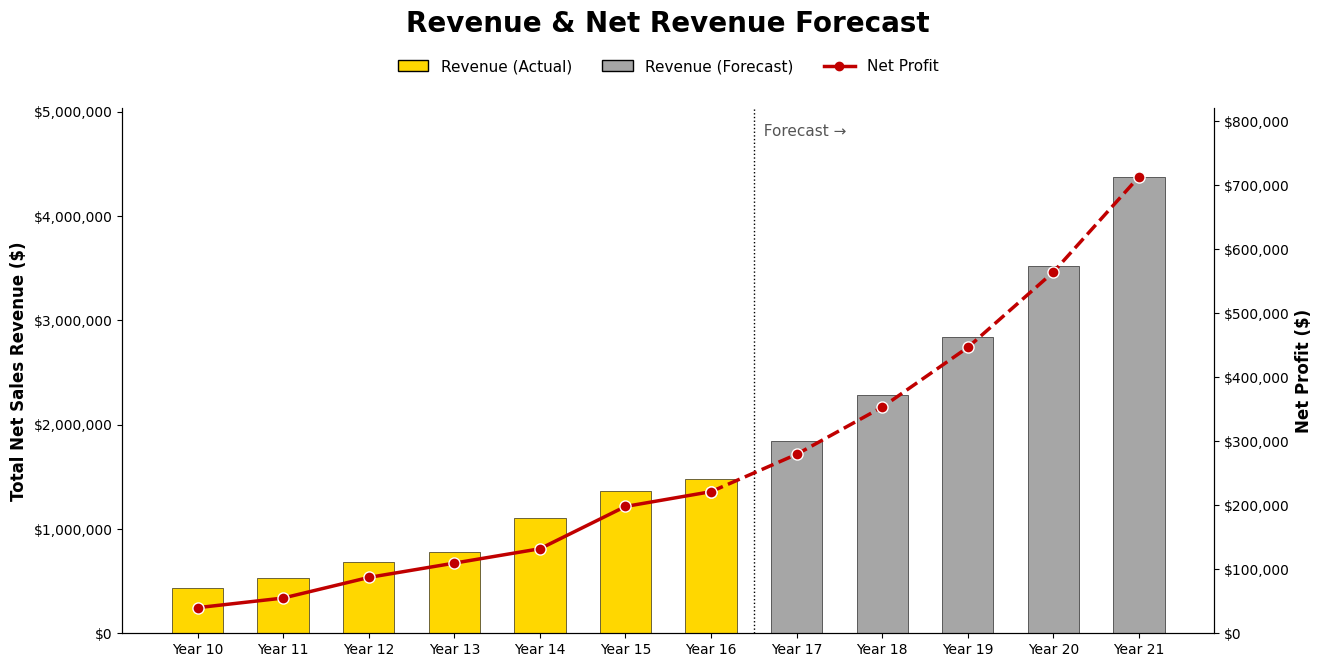

In [6]:
"""
Revenue vs Net Revenue chart, styled like the reference image:
- Blue bars   = Historical Revenue (left axis)
- Gray bars   = Forecasted Revenue (left axis)
- Red line    = Net Revenue / Earnings, historical + forecast (right axis)
- Dual y-axis, matching the reference "Revenue ($M) / Earnings ($M)" layout
"""
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---- 1. Historical data (edit to match your real numbers) ----
hist_years = ["Year 10", "Year 11", "Year 12", "Year 13", "Year 14", "Year 15", "Year 16"]

total_revenue = [432646, 526645, 681942, 774898, 1109359, 1360881, 1483316]
net_revenue   = [40000, 55039, 87219, 109609, 132042, 198126, 221235]

# ---- 2. Forecast 5 years ahead using CAGR of the last 3 historical years ----
n_forecast = 5

def cagr(series, periods):
    start, end = series[-(periods + 1)], series[-1]
    return (end / start) ** (1 / periods) - 1

rev_growth = cagr(total_revenue, 3)
net_growth = cagr(net_revenue, 3)

forecast_years = [f"Year {17 + i}" for i in range(n_forecast)]

fcst_revenue = []
fcst_net = []
last_rev, last_net = total_revenue[-1], net_revenue[-1]
for _ in range(n_forecast):
    last_rev = last_rev * (1 + rev_growth)
    last_net = last_net * (1 + net_growth)
    fcst_revenue.append(last_rev)
    fcst_net.append(last_net)

years = hist_years + forecast_years
all_revenue = total_revenue + fcst_revenue
all_net = net_revenue + fcst_net
n_hist = len(hist_years)

x = range(len(years))

# ---- 3. Plot ----
fig, ax1 = plt.subplots(figsize=(13, 7.5))
ax2 = ax1.twinx()

HIST_BAR = "#FFD700"   # blue
FCST_BAR = "#A6A6A6"   # gray
LINE_COLOR = "#C00000" # red

bar_colors = [HIST_BAR] * n_hist + [FCST_BAR] * n_forecast

ax1.bar(
    x, all_revenue,
    color=bar_colors, edgecolor="black", linewidth=0.4,
    width=0.6, zorder=2
)

# Red line — Net Revenue / Earnings (solid historical, dashed forecast)
ax2.plot(
    x[:n_hist], all_net[:n_hist],
    color=LINE_COLOR, linewidth=2.5, marker="o", markersize=8,
    markerfacecolor=LINE_COLOR, markeredgecolor="white", markeredgewidth=1, zorder=3
)
ax2.plot(
    x[n_hist - 1:], all_net[n_hist - 1:],
    color=LINE_COLOR, linewidth=2.5, linestyle="--", marker="o", markersize=8,
    markerfacecolor=LINE_COLOR, markeredgecolor="white", markeredgewidth=1, zorder=3
)

# ---- 4. Formatting ----
ax1.set_title("Revenue & Net Revenue Forecast", fontsize=20, fontweight="bold", pad=55)
ax1.set_ylabel("Total Net Sales Revenue ($)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Net Profit ($)", fontsize=12, fontweight="bold")

ax1.set_xticks(list(x))
ax1.set_xticklabels(years, fontsize=10)

ax1.set_ylim(0, max(all_revenue) * 1.15)
ax2.set_ylim(0, max(all_net) * 1.15)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"${v:,.0f}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"${v:,.0f}"))

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# Divider between historical and forecast
ax1.axvline(n_hist - 0.5, color="black", linewidth=1, linestyle=":", zorder=1)
ax1.text(n_hist - 0.5, max(all_revenue) * 1.10, "  Forecast \u2192", fontsize=11,
          color="#555555", ha="left", va="center")

ax1.legend(
    handles=[
        Patch(facecolor=HIST_BAR, edgecolor="black", label="Revenue (Actual)"),
        Patch(facecolor=FCST_BAR, edgecolor="black", label="Revenue (Forecast)"),
        Line2D([0], [0], color=LINE_COLOR, linewidth=2.5, marker="o",
               markerfacecolor=LINE_COLOR, label="Net Profit"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 1.12),
    ncol=3, frameon=False, fontsize=11
)

plt.subplots_adjust(top=0.80, bottom=0.1, left=0.08, right=0.92)
plt.savefig("revenue_forecast_chart.png", dpi=200)
plt.show()

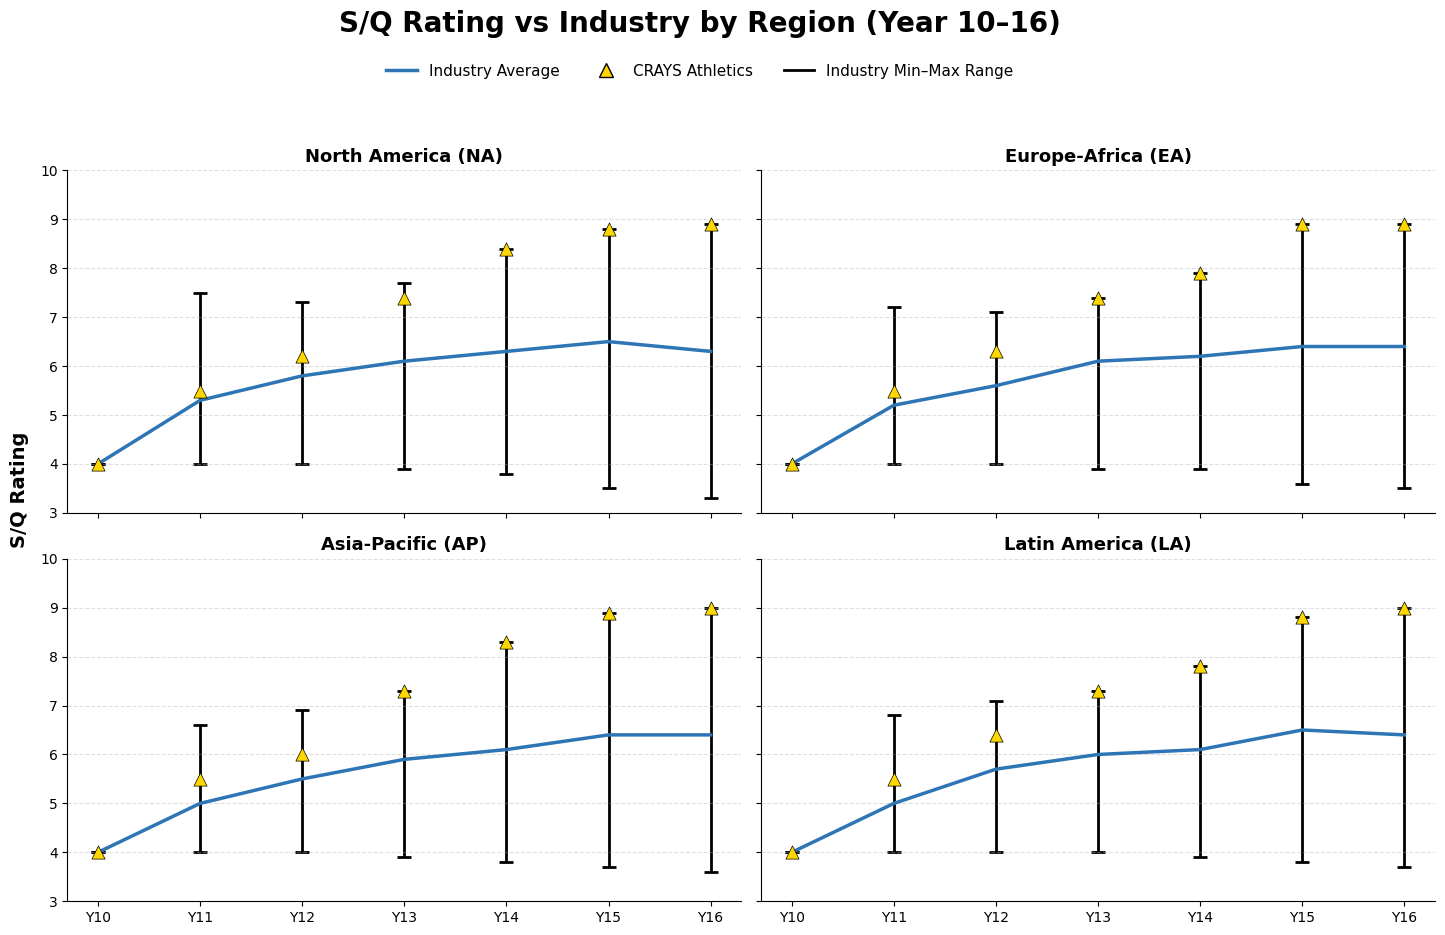

In [7]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# -----------------------------
# Years
# -----------------------------
years = ["Y10", "Y11", "Y12", "Y13", "Y14", "Y15", "Y16"]
x = range(len(years))

# -----------------------------
# Data
# -----------------------------
data = {
    "North America (NA)": {
        "avg":[4,5.3,5.8,6.1,6.3,6.5,6.3],
        "min":[4,4,4,3.9,3.8,3.5,3.3],
        "max":[4,7.5,7.3,7.7,8.4,8.8,8.9],
        "crays":[4,5.50,6.20,7.40,8.40,8.80,8.90]
    },

    "Europe-Africa (EA)": {
        "avg":[4,5.2,5.6,6.1,6.2,6.4,6.4],
        "min":[4,4,4,3.9,3.9,3.6,3.5],
        "max":[4,7.2,7.1,7.4,7.9,8.9,8.9],
        "crays":[4,5.50,6.30,7.40,7.90,8.90,8.90]
    },

    "Asia-Pacific (AP)": {
        "avg":[4, 5, 5.5, 5.9, 6.1, 6.4, 6.4],
        "min":[4,4,4,3.9,3.8,3.7,3.6],
        "max":[4,6.6,6.9,7.3,8.3,8.9,9.0],
        "crays":[4,5.50,6.00,7.30,8.30,8.90,9.00]
    },

    "Latin America (LA)": {
        "avg":[4, 5, 5.7, 6, 6.1, 6.5, 6.4],
        "min":[4,4,4,4,3.9,3.8,3.7],
        "max":[4,6.8,7.1,7.3,7.8,8.8,9.0],
        "crays":[4,5.50,6.40,7.30,7.80,8.80,9.00]
    }
}

# -----------------------------
# Plot Function
# -----------------------------
def plot_region(ax, title, avg, low, high, crays):

    lower_err = [a-l for a,l in zip(avg,low)]
    upper_err = [h-a for h,a in zip(high,avg)]

    # Industry Range
    ax.errorbar(
        x,
        avg,
        yerr=[lower_err, upper_err],
        fmt="none",
        ecolor="black",
        elinewidth=2,
        capsize=5,
        capthick=2,
        zorder=1
    )

    # Industry Average
    ax.plot(
        x,
        avg,
        color="#2E75B6",
        linewidth=2.5,
        zorder=2
    )

    # CRAYS
    ax.scatter(
        x,
        crays,
        marker="^",
        s=90,
        color="#FFD700",
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    ax.set_title(title, fontsize=13, fontweight="bold")

    ax.set_xticks(list(x))
    ax.set_xticklabels(years, fontsize=10)

    # -----------------------------
    # Better Scale
    # -----------------------------
    ax.set_ylim(3,10)
    ax.yaxis.set_major_locator(MultipleLocator(1))

    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)

    ax.grid(axis="y",
            linestyle="--",
            linewidth=0.8,
            alpha=0.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -----------------------------
# Figure
# -----------------------------
fig, axs = plt.subplots(
    2,
    2,
    figsize=(15,10),
    sharex=True,
    sharey=True
)

axs = axs.flatten()

for ax,(region,values) in zip(axs,data.items()):
    plot_region(
        ax,
        region,
        values["avg"],
        values["min"],
        values["max"],
        values["crays"]
    )

# -----------------------------
# Shared Y Label
# -----------------------------
fig.text(
    0.04,
    0.5,
    "S/Q Rating",
    rotation=90,
    va="center",
    fontsize=14,
    fontweight="bold"
)

# -----------------------------
# Title
# -----------------------------
fig.suptitle(
    "S/Q Rating vs Industry by Region (Year 10–16)",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# -----------------------------
# Legend
# -----------------------------
legend_handles = [
    Line2D([0],[0],
           color="#2E75B6",
           lw=2.5,
           label="Industry Average"),

    Line2D([0],[0],
           marker="^",
           color="w",
           markerfacecolor="#FFD700",
           markeredgecolor="black",
           markersize=10,
           label="CRAYS Athletics"),

    Line2D([0],[0],
           color="black",
           lw=2,
           label="Industry Min–Max Range")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5,0.94),
    ncol=3,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0.05,0.05,1,0.90])

plt.savefig(
    "SQ_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

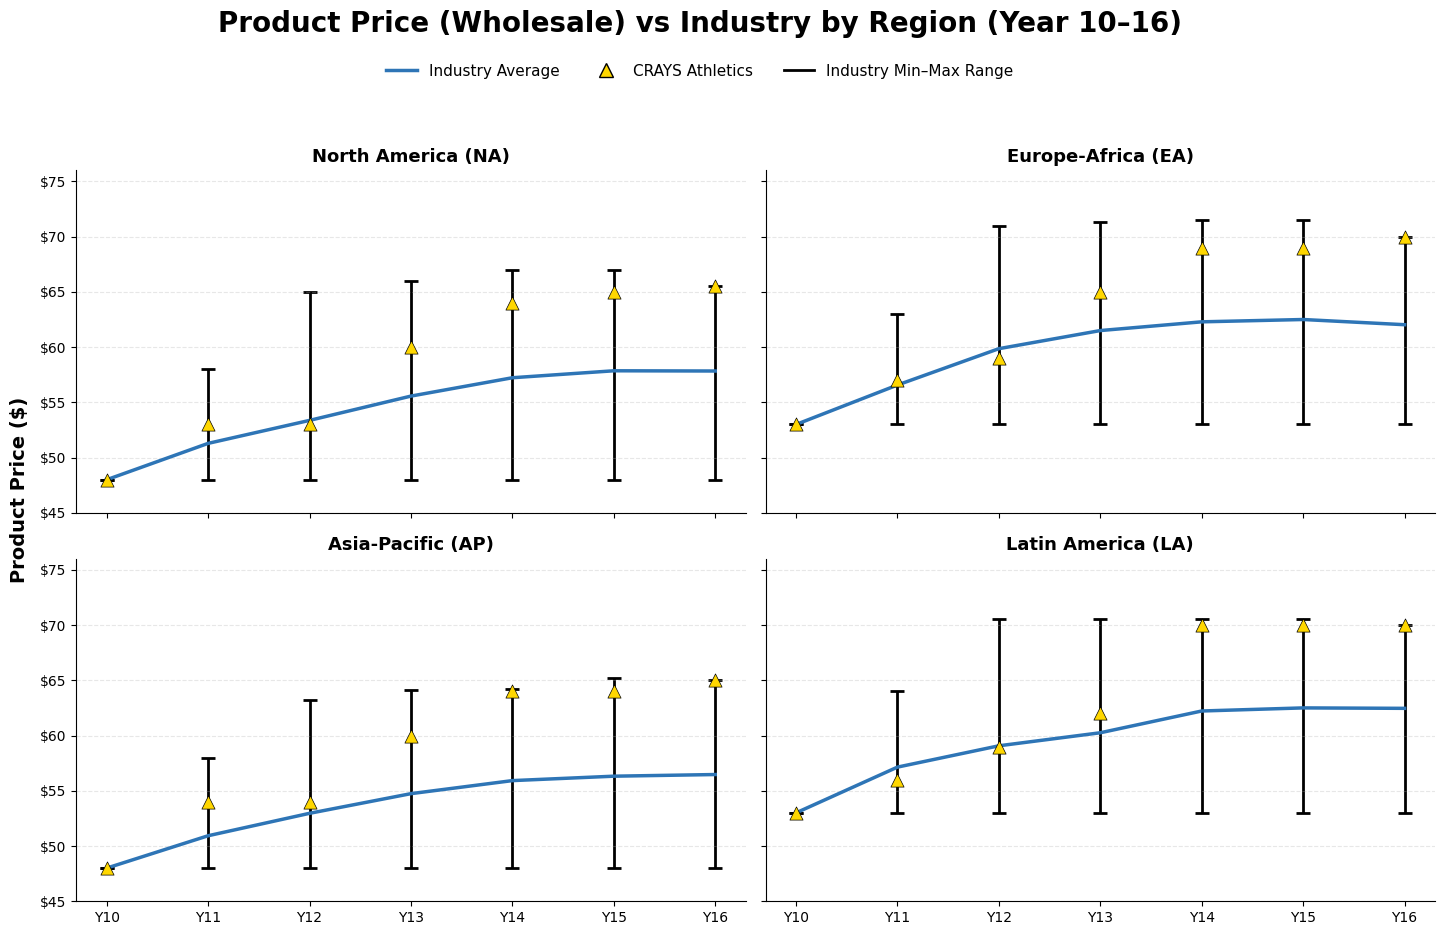

In [8]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, FuncFormatter

# -----------------------------
# Years
# -----------------------------
years = ["Y10", "Y11", "Y12", "Y13", "Y14", "Y15", "Y16"]
x = range(len(years))

# =====================================================
# REPLACE THESE WITH YOUR OWN WHOLESALE PRICE DATA
# =====================================================

data = {
    "North America (NA)": {
        "avg":   [48, 51.29, 53.37, 55.57, 57.23, 57.86, 57.84],
        "min":   [48, 48, 48, 48, 48, 48, 48],
        "max":   [48, 58, 65, 66.02, 67, 67, 65.50],
        "crays": [48, 53, 53, 60, 64, 65, 65.50]
    },

    "Europe-Africa (EA)": {
        "avg":   [53, 56.57, 59.86, 61.50, 62.29, 62.50, 62.03],
        "min":   [53, 53, 53, 53, 53, 53, 53],
        "max":   [53, 63, 71, 71.32, 71.50, 71.50, 70],
        "crays": [53, 57, 59, 65, 69, 69, 70]
    },
     "Asia-Pacific (AP)": {
        "avg":   [48, 50.93, 52.96, 54.74, 55.92, 56.32, 56.47],
        "min":   [48, 48, 48, 48, 48, 48, 48],
        "max":   [48, 58, 63.25, 64.15, 64.25, 65.25, 65],
        "crays": [48, 54, 54, 60, 64, 64, 65]
    },

    "Latin America (LA)": {
        "avg":   [53, 57.14, 59.07, 60.25, 62.22, 62.50, 62.46],
        "min":   [53, 53, 53, 53, 53, 53, 53],
        "max":   [53, 64, 70.50, 70.53, 70.53, 70.53, 70],
        "crays": [53, 56, 59, 62, 70, 70, 70]
    }
}

# -----------------------------
# Plot Function
# -----------------------------
def plot_region(ax, title, avg, low, high, crays):

    lower_err = [a - l for a, l in zip(avg, low)]
    upper_err = [h - a for h, a in zip(high, avg)]

    # Industry Min-Max Range
    ax.errorbar(
        x,
        avg,
        yerr=[lower_err, upper_err],
        fmt="none",
        ecolor="black",
        elinewidth=2,
        capsize=5,
        capthick=2,
        zorder=1
    )

    # Industry Average
    ax.plot(
        x,
        avg,
        color="#2E75B6",
        linewidth=2.5,
        zorder=2
    )

    # CRAYS
    ax.scatter(
        x,
        crays,
        marker="^",
        s=90,
        color="#FFD700",
        edgecolor="black",
        linewidth=0.5,
        zorder=3
    )

    ax.set_title(title, fontsize=13, fontweight="bold")

    ax.set_xticks(list(x))
    ax.set_xticklabels(years, fontsize=10)

    # Price axis
    ax.set_ylim(45, 76)
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: f"${y:.0f}")
    )

    ax.grid(axis="y", linestyle="--", alpha=0.3)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -----------------------------
# Create Figure
# -----------------------------
fig, axs = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharex=True,
    sharey=True
)

axs = axs.flatten()

for ax, (region, values) in zip(axs, data.items()):
    plot_region(
        ax,
        region,
        values["avg"],
        values["min"],
        values["max"],
        values["crays"]
    )

# -----------------------------
# Shared Y Label
# -----------------------------
fig.text(
    0.04,
    0.5,
    "Product Price ($)",
    rotation=90,
    va="center",
    fontsize=14,
    fontweight="bold"
)

# -----------------------------
# Overall Title
# -----------------------------
fig.suptitle(
    "Product Price (Wholesale) vs Industry by Region (Year 10–16)",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

# -----------------------------
# Legend
# -----------------------------
legend = [
    Line2D([0], [0],
           color="#2E75B6",
           lw=2.5,
           label="Industry Average"),

    Line2D([0], [0],
           marker="^",
           color="w",
           markerfacecolor="#FFD700",
           markeredgecolor="black",
           markersize=10,
           label="CRAYS Athletics"),

    Line2D([0], [0],
           color="black",
           lw=2,
           label="Industry Min–Max Range")
]

fig.legend(
    handles=legend,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=3,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.90])

plt.savefig("Wholesale_Price_by_Region.png", dpi=300, bbox_inches="tight")

plt.show()

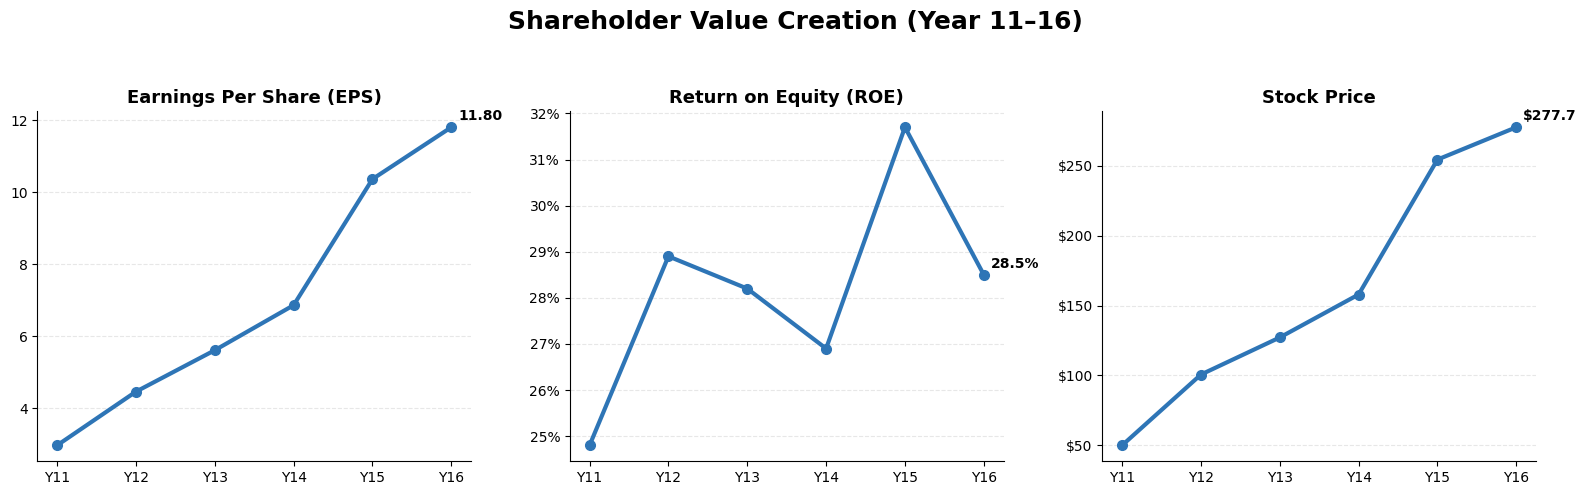

In [9]:
from matplotlib.ticker import FuncFormatter

# -----------------------------
# Data (Replace with your data)
# -----------------------------
years = ["Y11","Y12","Y13","Y14","Y15","Y16"]

eps = [2.97, 4.46, 5.61, 6.86, 10.36, 11.80]

roe = [24.8, 28.9, 28.2, 26.9, 31.7, 28.5]

stock = [49.83, 100.54, 127.12, 157.90, 254.55, 277.73]

# -----------------------------
# Create dashboard
# -----------------------------
fig, axs = plt.subplots(1, 3, figsize=(16,5))

# ========= EPS ==========
axs[0].plot(
    years,
    eps,
    color="#2E75B6",
    marker="o",
    linewidth=3,
    markersize=7
)

axs[0].set_title("Earnings Per Share (EPS)",
                 fontsize=13,
                 fontweight="bold")

axs[0].grid(axis='y', linestyle='--', alpha=0.3)

axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[0].annotate(
    f"{eps[-1]:.2f}",
    (years[-1], eps[-1]),
    xytext=(5,5),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

# ========= ROE ==========
axs[1].plot(
    years,
    roe,
    color="#2E75B6",
    marker="o",
    linewidth=3,
    markersize=7
)

axs[1].set_title("Return on Equity (ROE)",
                 fontsize=13,
                 fontweight="bold")

axs[1].yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0f}%")
)

axs[1].grid(axis='y', linestyle='--', alpha=0.3)

axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[1].annotate(
    f"{roe[-1]:.1f}%",
    (years[-1], roe[-1]),
    xytext=(5,5),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

# ========= Stock Price ==========
axs[2].plot(
    years,
    stock,
    color="#2E75B6",
    marker="o",
    linewidth=3,
    markersize=7
)

axs[2].set_title("Stock Price",
                 fontsize=13,
                 fontweight="bold")

axs[2].yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"${y:.0f}")
)

axs[2].grid(axis='y', linestyle='--', alpha=0.3)

axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)

axs[2].annotate(
    f"${stock[-1]:.1f}",
    (years[-1], stock[-1]),
    xytext=(5,5),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

# -----------------------------
# Overall Title
# -----------------------------
fig.suptitle(
    "Shareholder Value Creation (Year 11–16)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.93])

plt.savefig(
    "Shareholder_Value_Dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

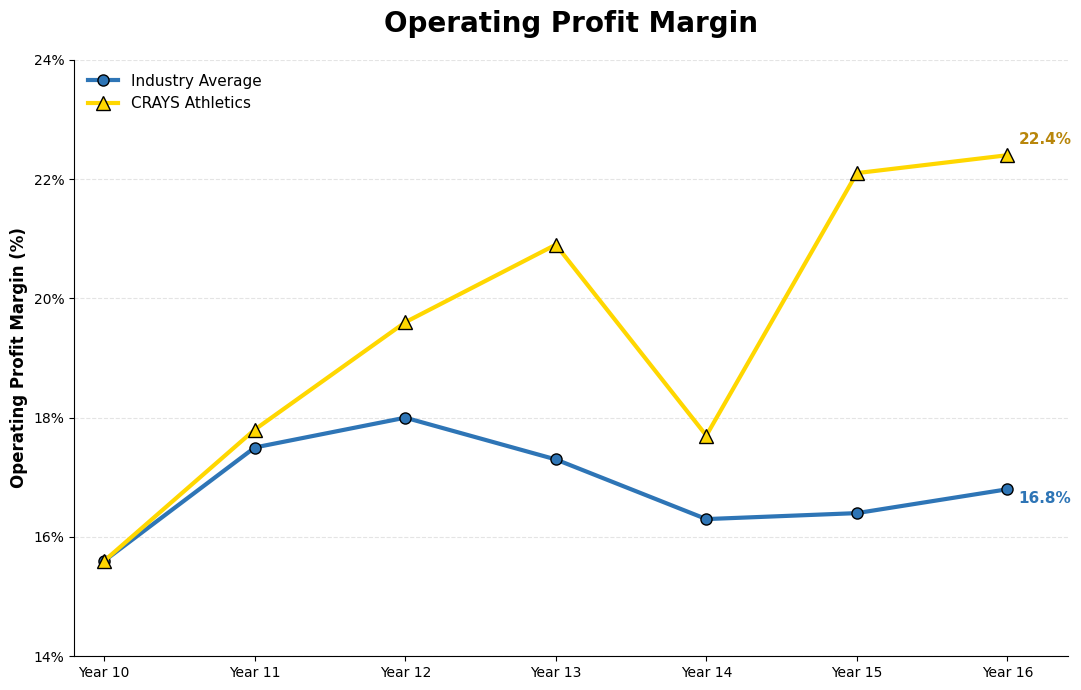

In [10]:
from matplotlib.ticker import FuncFormatter

# -----------------------------
# Data
# -----------------------------
years = ["Year 10", "Year 11", "Year 12", "Year 13",
         "Year 14", "Year 15", "Year 16"]

industry_avg = [15.6, 17.5, 18.0, 17.3, 16.3, 16.4, 16.8]
crays = [15.6, 17.8, 19.6, 20.9, 17.7, 22.1, 22.4]

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 7))

# Plain white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# -----------------------------
# Industry Average
# -----------------------------
ax.plot(
    years,
    industry_avg,
    color="#2E75B6",
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor="#2E75B6",
    markeredgecolor="black",
    label="Industry Average"
)

# -----------------------------
# CRAYS Athletics
# -----------------------------
ax.plot(
    years,
    crays,
    color="#FFD700",
    linewidth=3,
    marker="^",
    markersize=10,
    markerfacecolor="#FFD700",
    markeredgecolor="black",
    label="CRAYS Athletics"
)

# Leave room on right for labels
ax.set_xlim(-0.2, len(years) - 1 + 0.4)

# -----------------------------
# Show Year 16 values
# -----------------------------
ax.annotate(
    f"{industry_avg[-1]:.1f}%",
    xy=(years[-1], industry_avg[-1]),
    xytext=(8, -10),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    color="#2E75B6"
)

ax.annotate(
    f"{crays[-1]:.1f}%",
    xy=(years[-1], crays[-1]),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    color="#B8860B"
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_title(
    "Operating Profit Margin",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_ylabel(
    "Operating Profit Margin (%)",
    fontsize=12,
    fontweight="bold"
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0f}%")
)

# Set y-axis limits for better appearance
ax.set_ylim(14, 24)

# Grid
ax.grid(
    axis="y",
    color="lightgray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.6
)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    "Operating_Profit_Margin.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()